In [ ]:
import torch
import torch.nn as nn
from torch.optim import SGD
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [ ]:
# X = torch.tensor([[6, 2], [5, 2], [1, 3], [7, 6]]).float()
# y = torch.tensor([1, 5, 2, 5]).float()

# class NeuralNet(nn.Module):
#   def __init__(self,):
#     super().__init__()
#     self.Matrix1 = nn.Linear(2, 8)
#     self.Matrix2 = nn.Linear(8, 1)
#     self.relu = nn.ReLU()

#   def forward(self, x):
#     x = self.Matrix1(x)
#     # print(x)
#     x = self.Matrix2(x)
#     return x.squeeze()

#     # y = self.Matrix2(y)

# f = NeuralNet()
# opt = SGD(f.parameters(), lr = 0.001)
# L = nn.MSELoss()

# # train model
# losses = []
# predictions = []
# for _ in range(500):
#   opt.zero_grad() # flush previous epoch's gradient
#   predictions.append(f(X))
#   loss_val = L(f(X), y) # compute loss
#   loss_val.backward() # compute gradient
#   opt.step() # perform iteration using the calculated gradient
#   losses.append(loss_val)
# # yhat = f(X)
# # print(yhat)


# losses
# print(y)
# predictions[len(predictions) - 1]

## **MNIST**

In [ ]:
import torch
import torch.nn as nn
from torch.optim import SGD
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_openml


In [ ]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X_raw = mnist.data / 255    # images
y_raw = mnist.target    # labels

y_int = y_raw.astype(np.int64)
X = torch.tensor(X_raw, dtype=torch.float32)
# Reshape to images
X = X.view(-1, 28, 28)
y = torch.tensor(y_int, dtype=torch.long)


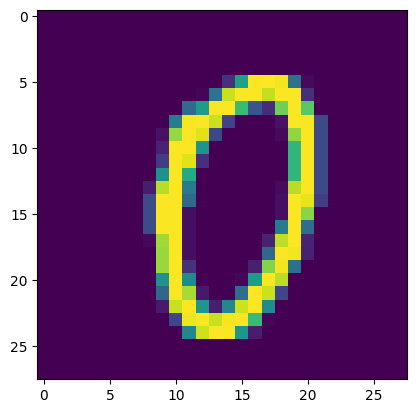

In [ ]:
plt.imshow(X[1000].numpy()) # individual data points

In [ ]:
class CTDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = F.one_hot(y, num_classes = 10).to(float)

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, index):
    return self.X[index], self.y[index]


In [ ]:
X_train = X[:60000]
y_train = y[:60000]
X_test = X[60000:]
y_test = y[60000:]
train = CTDataset(X_train, y_train)
test = CTDataset(X_test, y_test)
len(test)

10000

In [ ]:
train[0]

(tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000,

In [ ]:
train_dl = DataLoader(train, batch_size = 5) # creating the dataloader - helps in training,
len(train_dl)

12000

In [ ]:
class NeuralNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.Matrix1 = nn.Linear(28**2, 100)
    self.Matrix2 = nn.Linear(100, 50)
    self.Matrix3 = nn.Linear(50, 10)
    self.relu = nn.ReLU()

  def forward(self, X):
    X = X.view(-1, 28**2)
    X = self.relu(self.Matrix1(X))
    X = self.relu(self.Matrix2(X))
    X = self.Matrix3(X)
    return X.squeeze()



In [ ]:
xs, ys = train[0:4] # testing on small data sample if everything is working okay or not

f = NeuralNet() #initializing the network object
f(xs)

tensor([[ 0.0353, -0.1243, -0.0182, -0.0576, -0.0487,  0.0722,  0.0282,  0.0262,
         -0.0901,  0.0717],
        [ 0.0594, -0.0562,  0.0434, -0.0811, -0.0764,  0.1174,  0.0402, -0.0048,
         -0.0608,  0.0630],
        [ 0.0557, -0.0671,  0.0252, -0.0646, -0.0388,  0.0828,  0.0580, -0.0169,
         -0.0460,  0.0944],
        [ 0.0725, -0.0379,  0.0157, -0.0977, -0.0114,  0.0838,  0.0664, -0.0302,
          0.0031,  0.0845]], grad_fn=<SqueezeBackward0>)

In [ ]:
# training the model
test_dl = DataLoader(test, batch_size=64) # used to track validation loss
def training_loop(dl, f, n_epochs = 20):
  # dl is the dataloader we created, f is the network object, you already know what epoch is

  # ==== Optimizer ====
  opt = SGD(f.parameters(), lr = 0.01)
  LossFn = nn.CrossEntropyLoss()

  # ==== Training ====
  losses = []
  epochs = []
  val_losses = []

  for epoch in range(n_epochs):
    print(f'Epoch {epoch}')
    N = len(dl) # this is going to be 12000, as the batch size is 5 and the total size is 60000 in our dataloader
    for i, (x, y) in enumerate(dl): # (x, y) refers to the data and the label - provided by the dataloader
      opt.zero_grad() # removing gradients of previous epochs
      loss_value = LossFn(f(x), y) # f(x) returns predictions and is the label
      loss_value.backward() # updates weights
      opt.step()

      # tracking validation loss
      f.eval()
      val_loss = 0.0
      with torch.no_grad():
          for x_val, y_val in test_dl:
              val_loss += LossFn(f(x_val), y_val).item()

      val_loss /= len(test_dl)

      # storing training info
      epochs.append(epoch + 1 / N)
      losses.append(loss_value.item())
      val_losses.append(val_loss)
  return np.array(epochs), np.array(losses)



In [ ]:
epoch_cnt = 50
epoch_data, loss_data = training_loop(train_dl, f, n_epochs = epoch_cnt)

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13


In [ ]:
abc = loss_data.reshape(epoch_cnt, -1).mean(axis = 1)
abc

array([0.43831054, 0.16971061, 0.11552153, 0.08759854, 0.07013438,
       0.05738259, 0.04753016, 0.03983013, 0.0333231 , 0.02797892,
       0.02351367, 0.01915434, 0.01558212, 0.01294164, 0.01048579,
       0.00851892, 0.00696926, 0.00562545, 0.0047972 , 0.00381281])

Text(0.5, 1.0, 'Cross Entropy (per batch)')

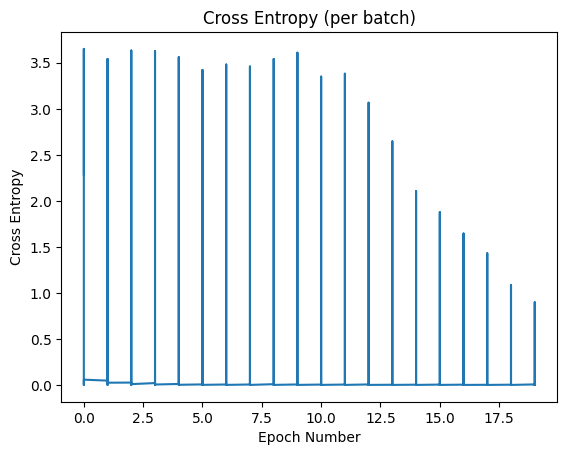

In [ ]:
plt.plot(epoch_data, loss_data)
plt.xlabel('Epoch Number')
plt.ylabel('Cross Entropy')
plt.title('Cross Entropy (per batch)')

(20,)


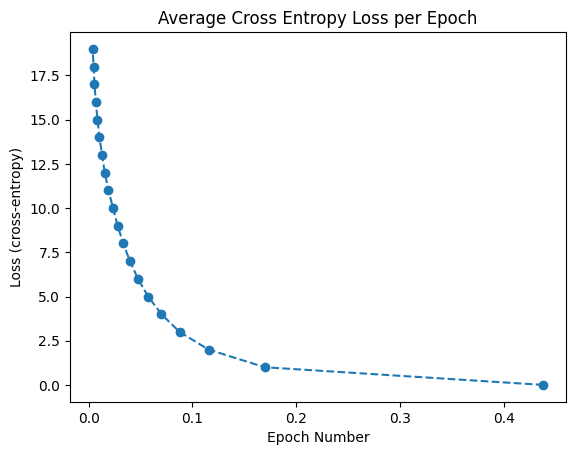

In [ ]:
# ==== Plotting the loss data ====
# there are 240,000 values - about 12,000 per epoch. we want to avg the loss per epoch, so we have only 20 values - 1 for each epoch
avg_loss_data = loss_data.reshape(epoch_cnt, -1).mean(axis = 1)
avg_epoch_data = epoch_data.reshape(epoch_cnt, -1).mean(axis = 1)
print(avg_loss_data.shape)

plt.plot(avg_loss_data, avg_epoch_data, 'o--')
plt.xlabel('Epoch Number')
plt.ylabel('Loss (cross-entropy)')
plt.title('Average Cross Entropy Loss per Epoch')
plt.show()

In [ ]:
print(avg_loss_data)

[0.09761583 0.09406311 0.09071589 0.087541   0.08451476 0.08164612
 0.07890747 0.07630613 0.07384239 0.07146809 0.06921071 0.06706849
 0.06500001 0.06302642 0.06113151 0.05929686 0.05753354 0.05583242
 0.05422303 0.05263909]


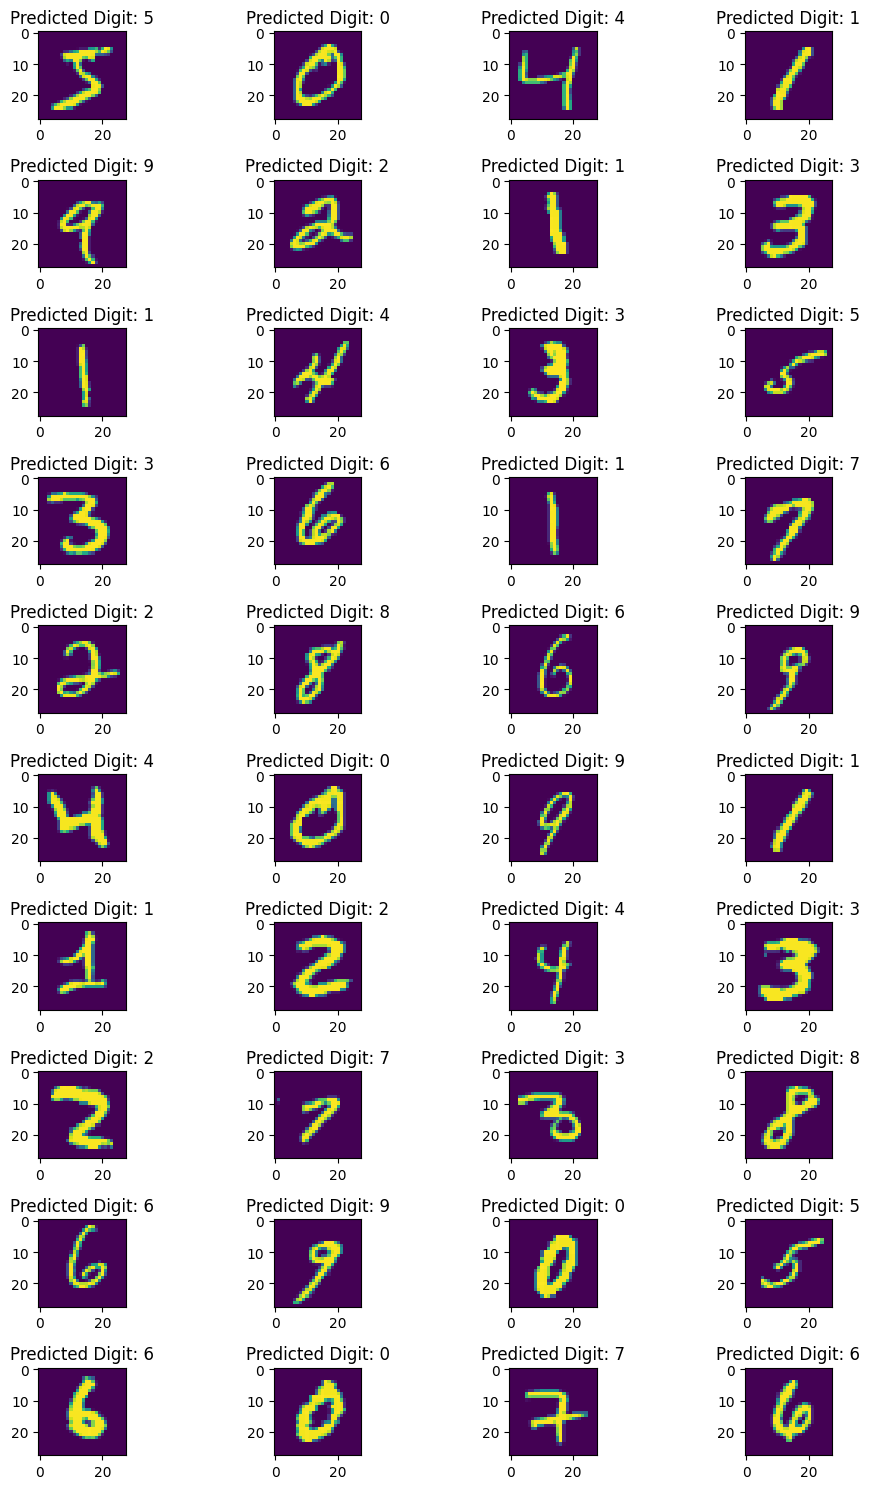

In [ ]:
xs, ys = train[0:40]
yhats = f(xs).argmax(axis=1)
fig, ax = plt.subplots(10,4,figsize=(10,15))
for i in range(40):
    plt.subplot(10,4,i+1)
    plt.imshow(xs[i])
    plt.title(f'Predicted Digit: {yhats[i]}')
fig.tight_layout()
plt.show()